5921910


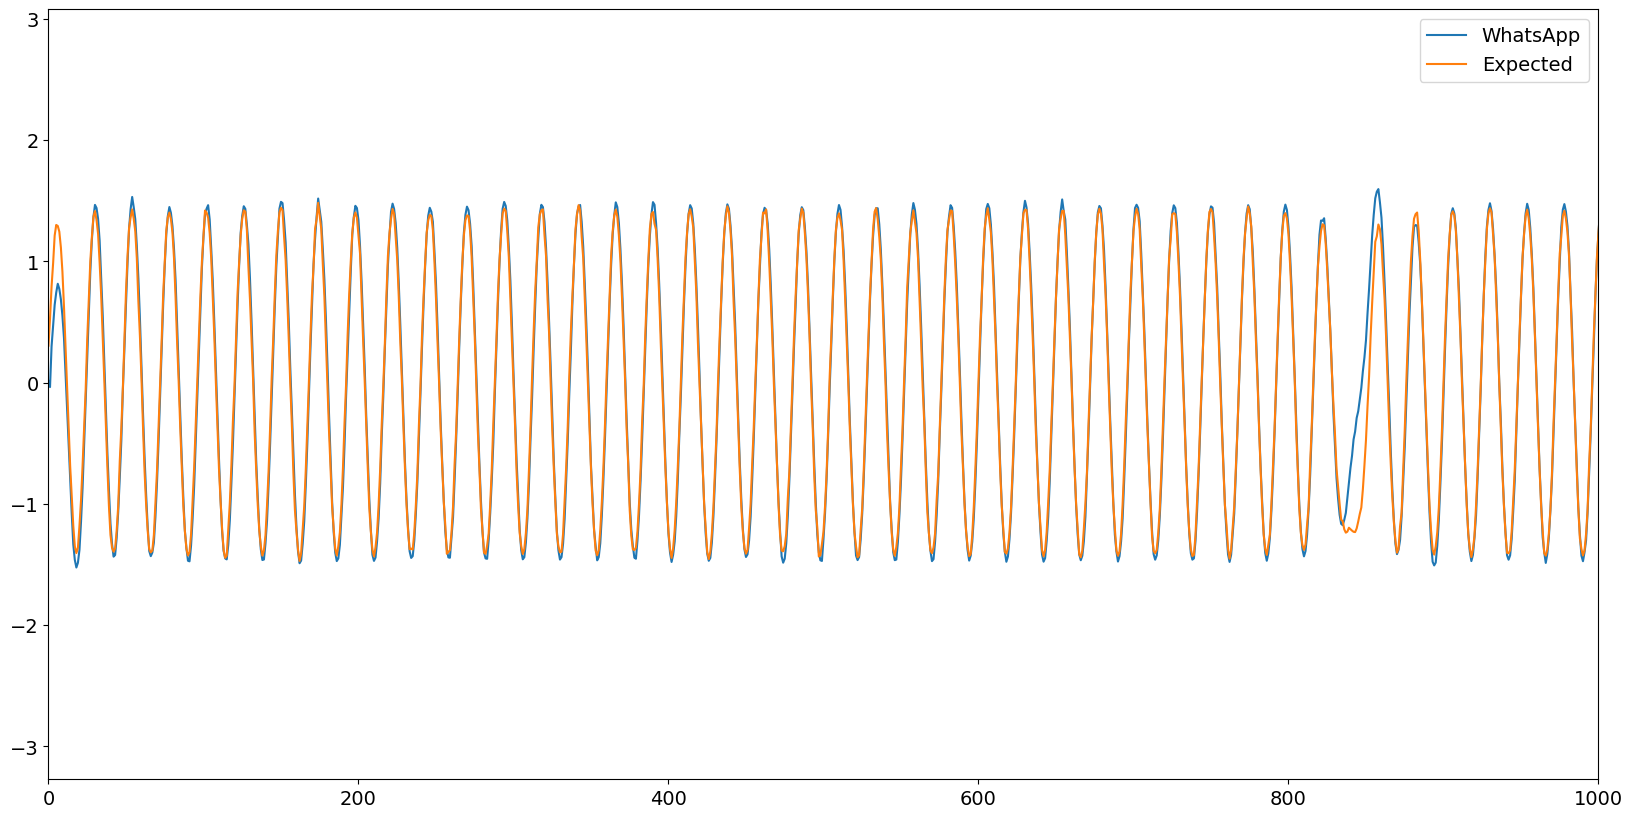

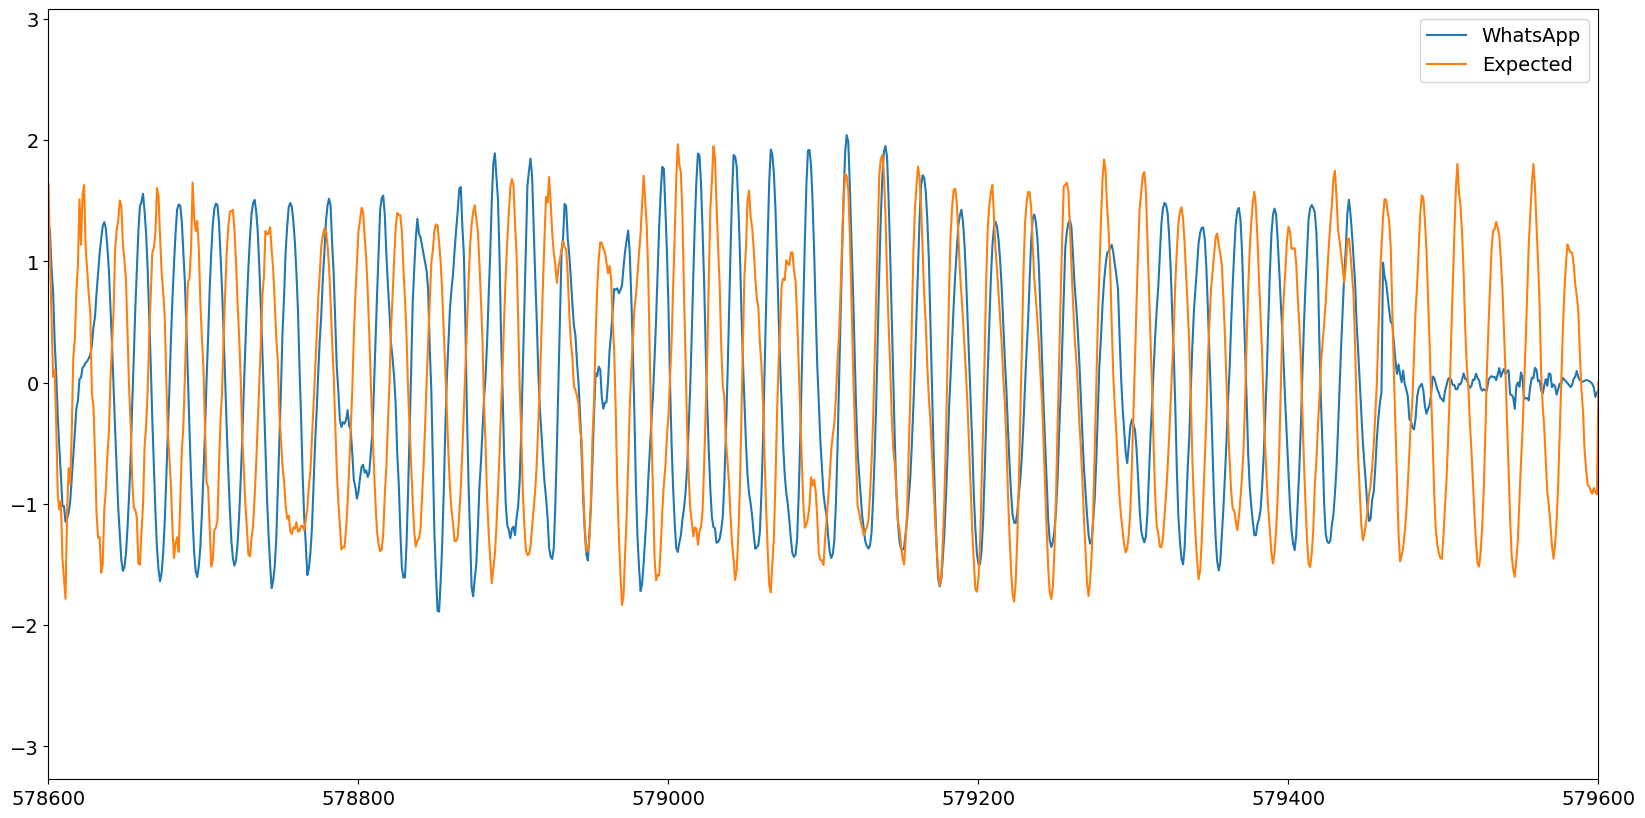

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update(
    {
        "axes.titlesize": 14,  # Title
        "axes.labelsize": 14,  # X and Y labels
        "xtick.labelsize": 14,  # X tick labels
        "ytick.labelsize": 14,  # Y tick labels
        "legend.fontsize": 14,  # Legend
    }
)


def plot_baseband(
    title: str,
    trimmed_waveform,
    phase,
    expected,
    samples_per_symbol,
    start: int = 0,
    end: int = 1000,
    save: bool = True,
    unlimited: bool = False,
):
    phase = np.angle(phase)
    expected = np.angle(expected)

    normalized_trimmed_waveform = trimmed_waveform / np.std(trimmed_waveform)
    normalized_phase = phase / np.std(phase)
    normalized_expected = expected / np.std(expected)

    # 13=barker code bits, 2=each symbol is repeated 2 times
    preamble_samples = samples_per_symbol * 13 * 7

    plt.figure(figsize=(20, 10))
    plt.title(title)
    plt.plot(normalized_trimmed_waveform[::10], label="trimmed waveform")
    plt.plot(normalized_phase[::10], label="phase", color="orange")
    plt.plot(normalized_expected[::10], label="expected", color="black")
    plt.plot(
        normalized_expected[:preamble_samples:10],
        label="expected preamble",
        color="purple",
    )

    if not unlimited:
        plt.xlim([start, end])
    plt.legend()
    if save:
        plt.savefig(f"../../output/{start}_{end}.pdf")


def print_everything(data, title: str, gap: int = 1000, max: int = 4000):
    trimmed_waveform = data["trimmed_waveform"]
    phase = data["phase"]
    expected = data["expected"]
    samples_per_symbol = data["samples_per_symbol"]
    for start in range(0, max, gap):
        end = start + gap
        plot_baseband(
            title,
            trimmed_waveform,
            phase,
            expected,
            samples_per_symbol,
            start,
            end,
            False,
        )
    plot_baseband(
        title,
        trimmed_waveform,
        phase,
        expected,
        samples_per_symbol,
        unlimited=True,
        save=False,
    )


def plot_wave_shift(
    title: str,
    wave_0,
    wave_1,
    start: int = 0,
    end: int = 1000,
    save: bool = True,
    unlimited: bool = False,
):

    wave_0 = wave_0 / np.std(wave_0)
    wave_1 = wave_1 / np.std(wave_1)

    plt.figure(figsize=(20, 10))
    plt.title(title)
    plt.plot(wave_0[::10], label="WhatsApp")
    plt.plot(wave_1[::10], label="Expected")

    if not unlimited:
        plt.xlim([start, end])
    plt.legend()
    if save:
        plt.savefig(
            f"../../output/{start}_{end}.pdf",
            bbox_inches="tight",
        )


def print_everything2(wave0, wave1, gap: int = 1000, max: int = 4000):

    for start in range(0, max, gap):
        end = start + gap
        plot_wave_shift(
            "",
            wave0["trimmed_waveform"] * -1,
            wave1["trimmed_waveform"],
            start,
            end,
            False,
        )
    plot_wave_shift(
        "",
        wave0["trimmed_waveform"] * -1,
        wave1["trimmed_waveform"],
        save=False,
        unlimited=True,
    )


whatsapp_data = np.load("../../output/clean_set_wa_long.npz", allow_pickle=True)
analytic_data = np.load("../../output/clean_set_analytic_long.npz", allow_pickle=True)
# print_everything2(whatsapp_data, analytic_data)
plot_wave_shift(
    "",
    whatsapp_data["trimmed_waveform"] * -1,
    analytic_data["trimmed_waveform"],
    0,
    1000,
    True,
)
print(analytic_data["trimmed_waveform"].shape[0])
plot_wave_shift(
    "",
    whatsapp_data["trimmed_waveform"] * -1,
    analytic_data["trimmed_waveform"],
    579600 - 1000,
    579600,
    True,
)

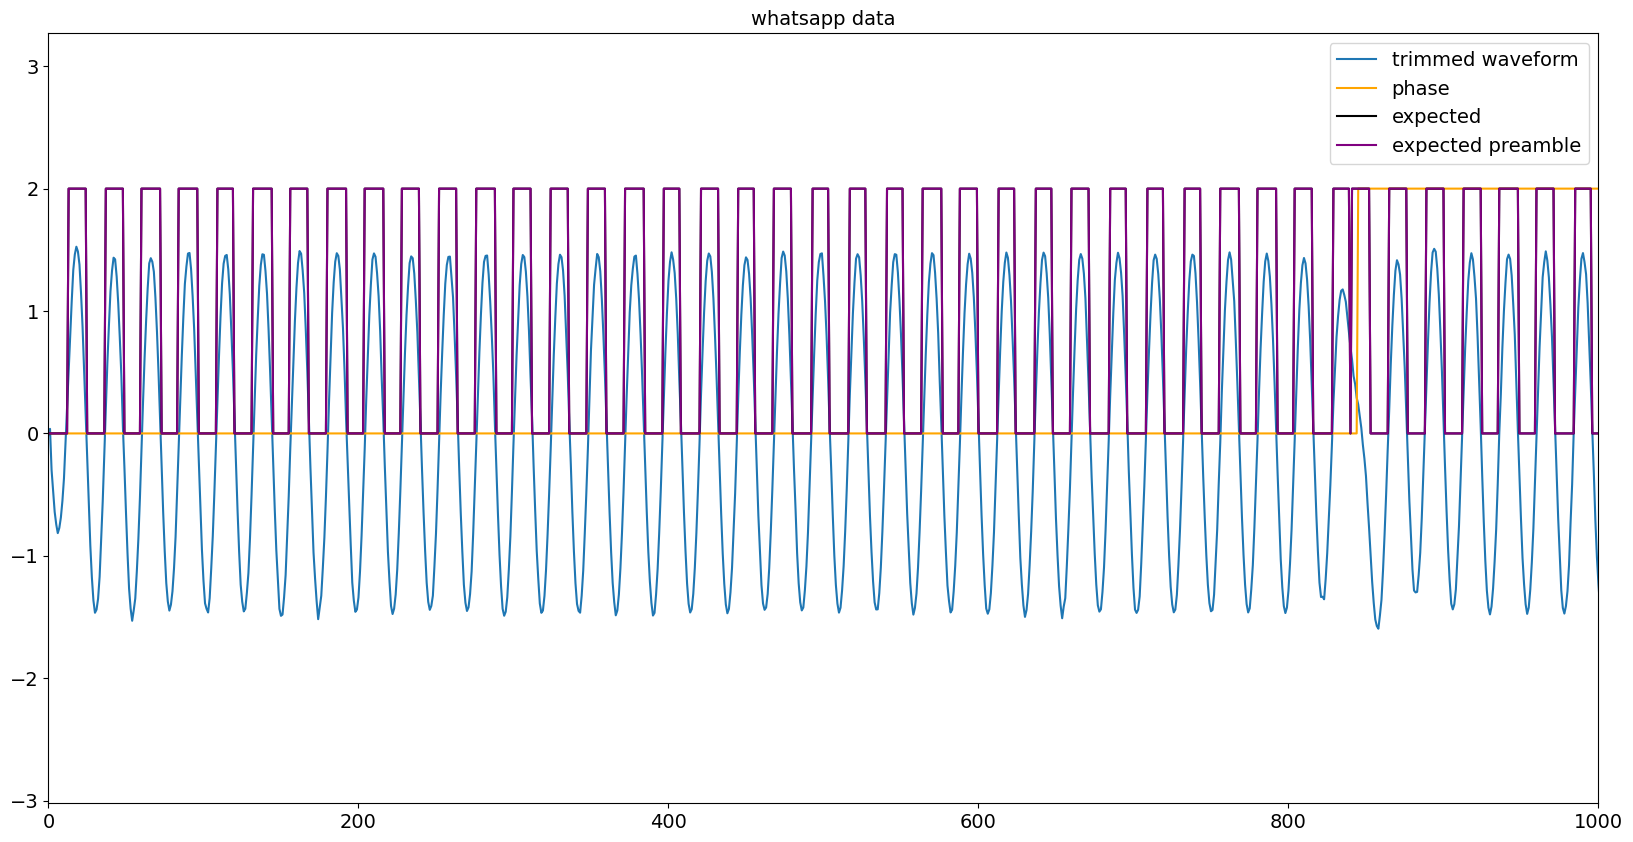

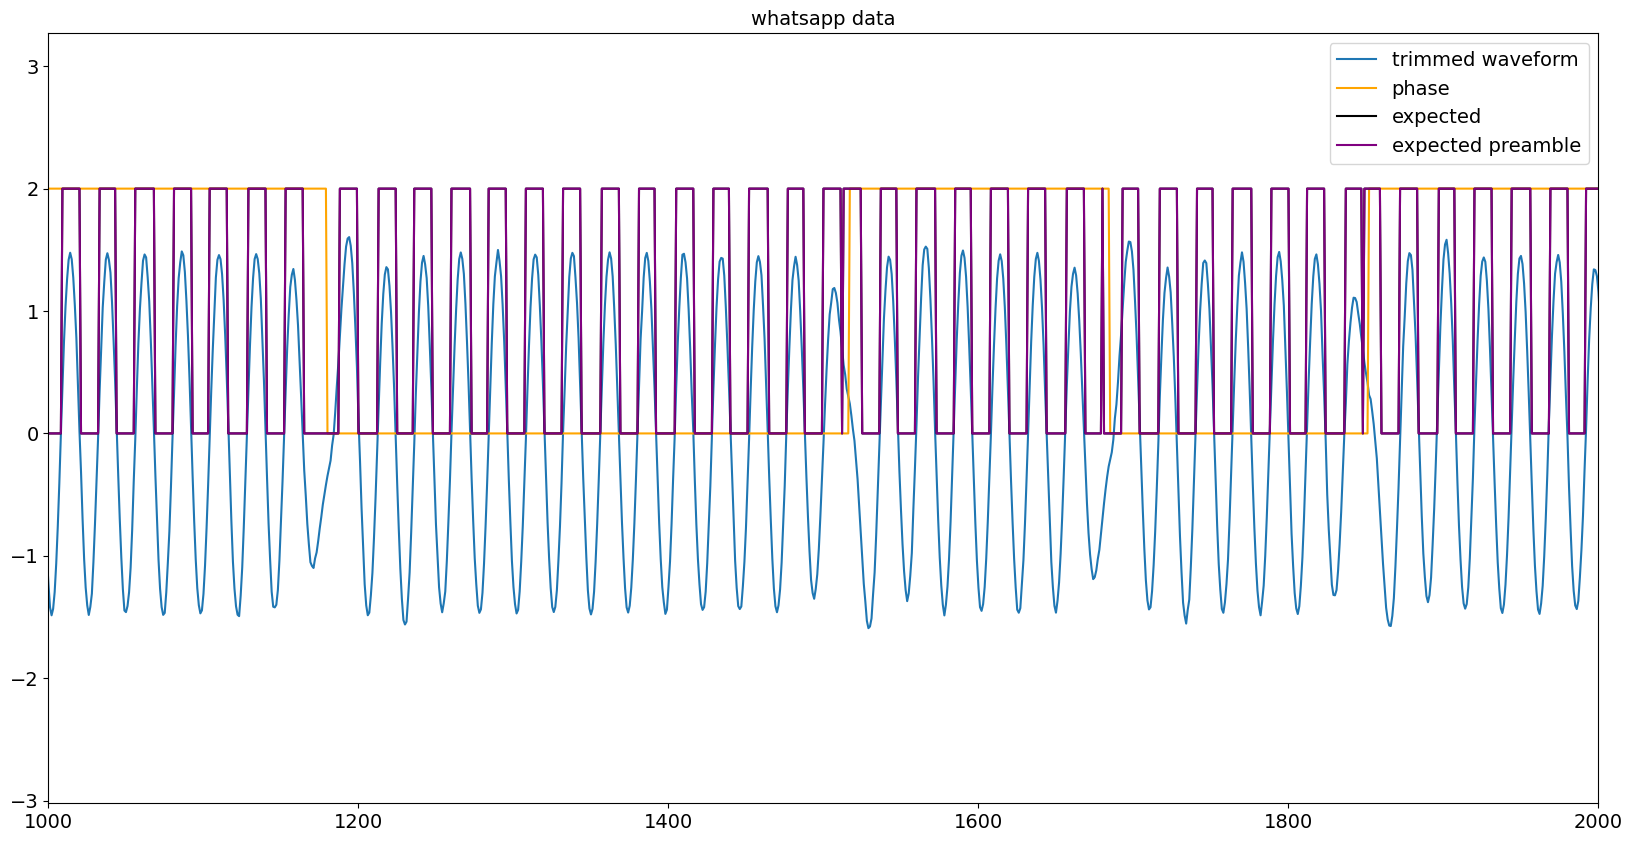

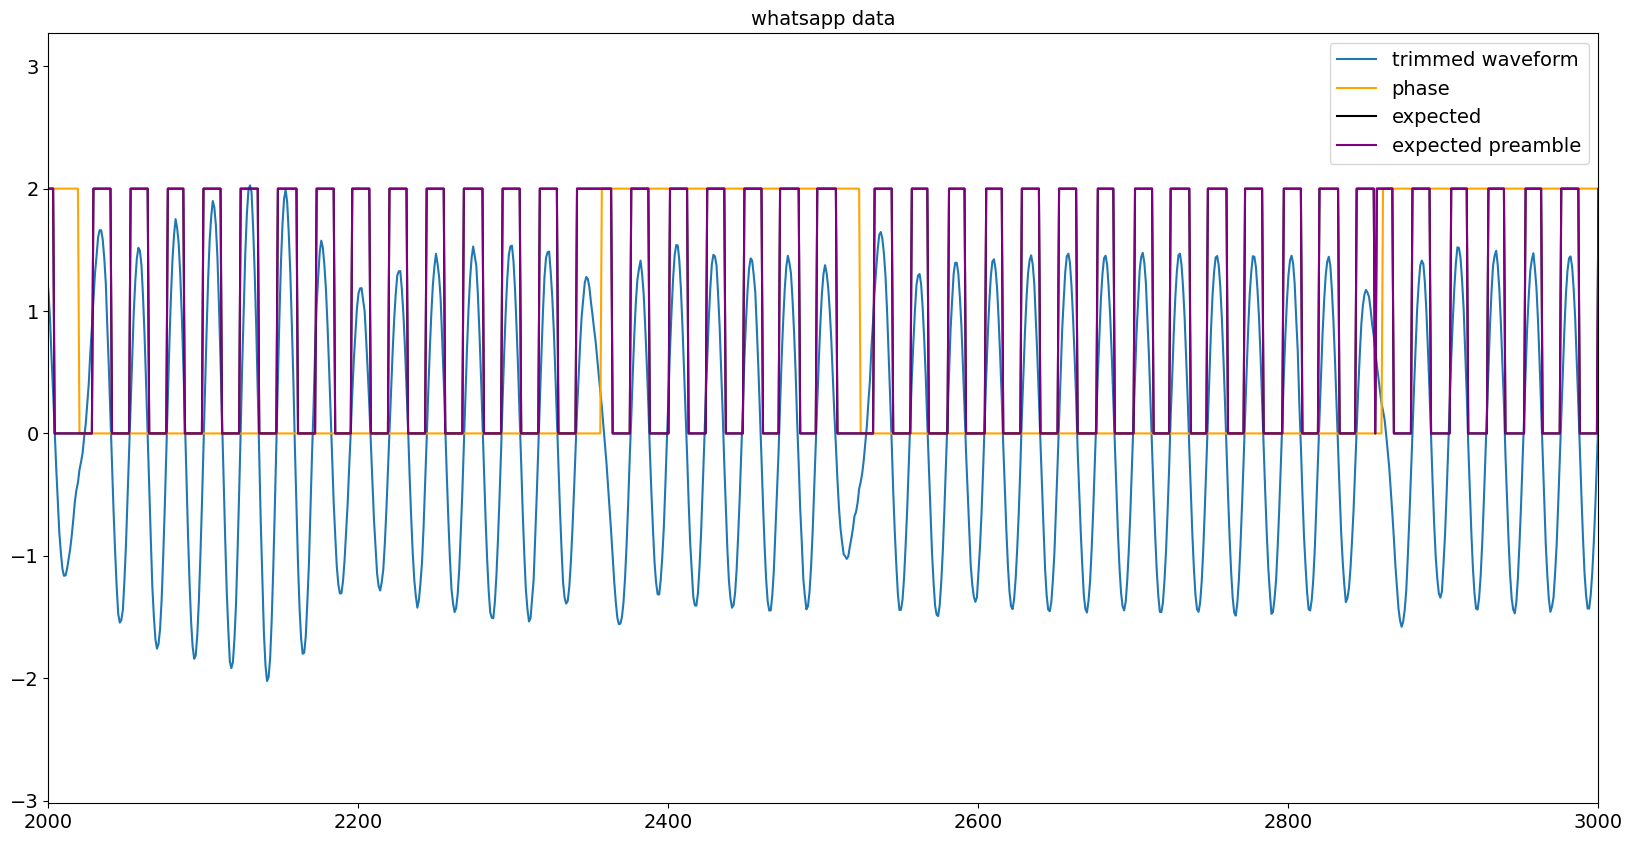

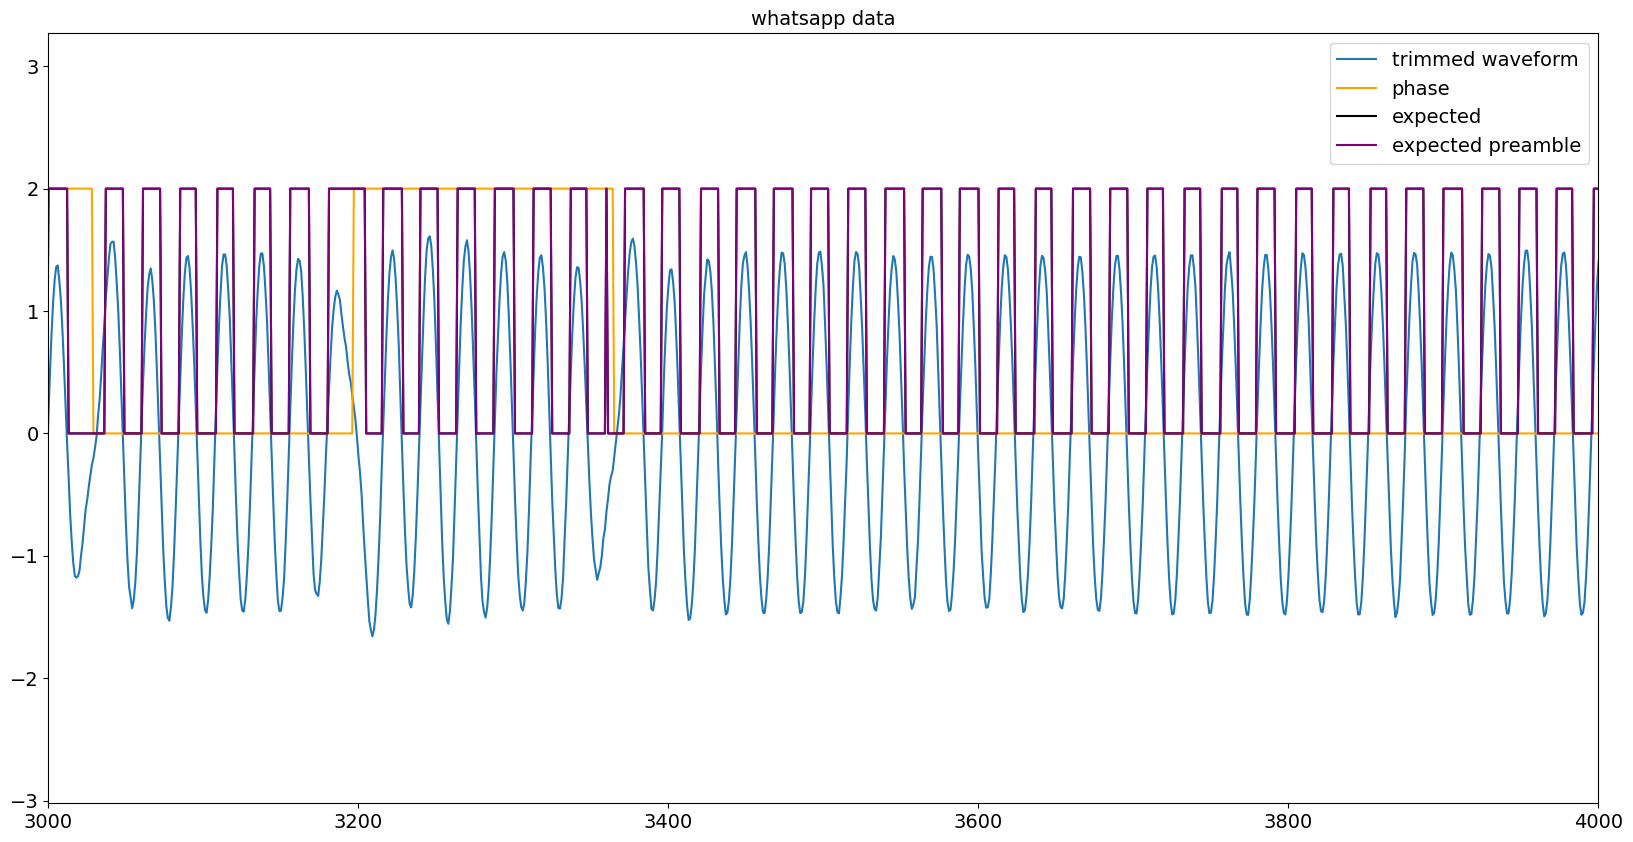

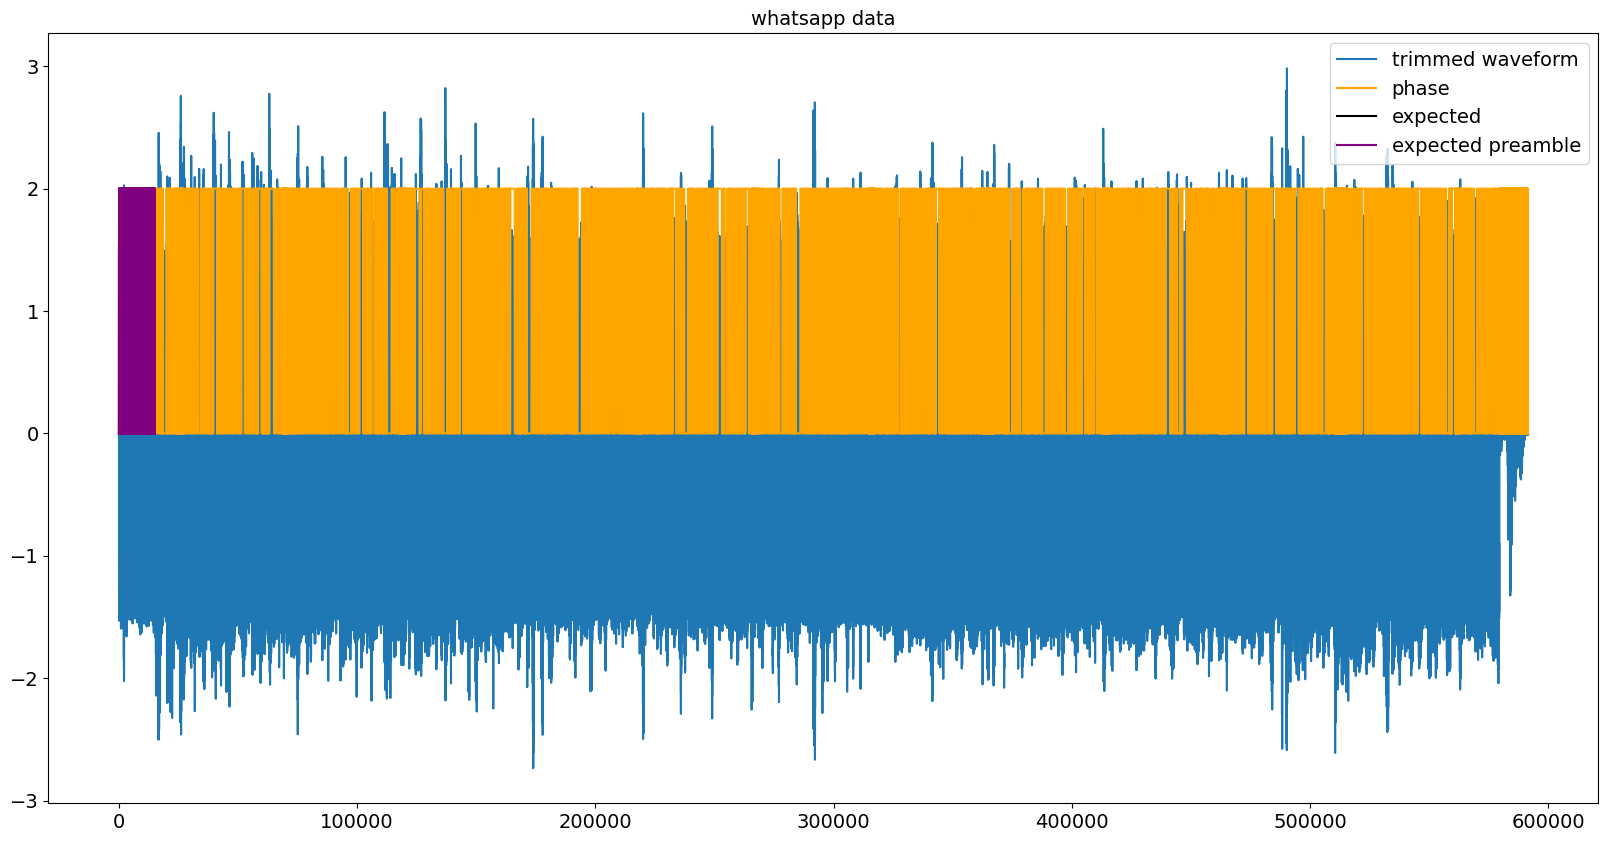

In [2]:
print_everything(whatsapp_data, "whatsapp data")

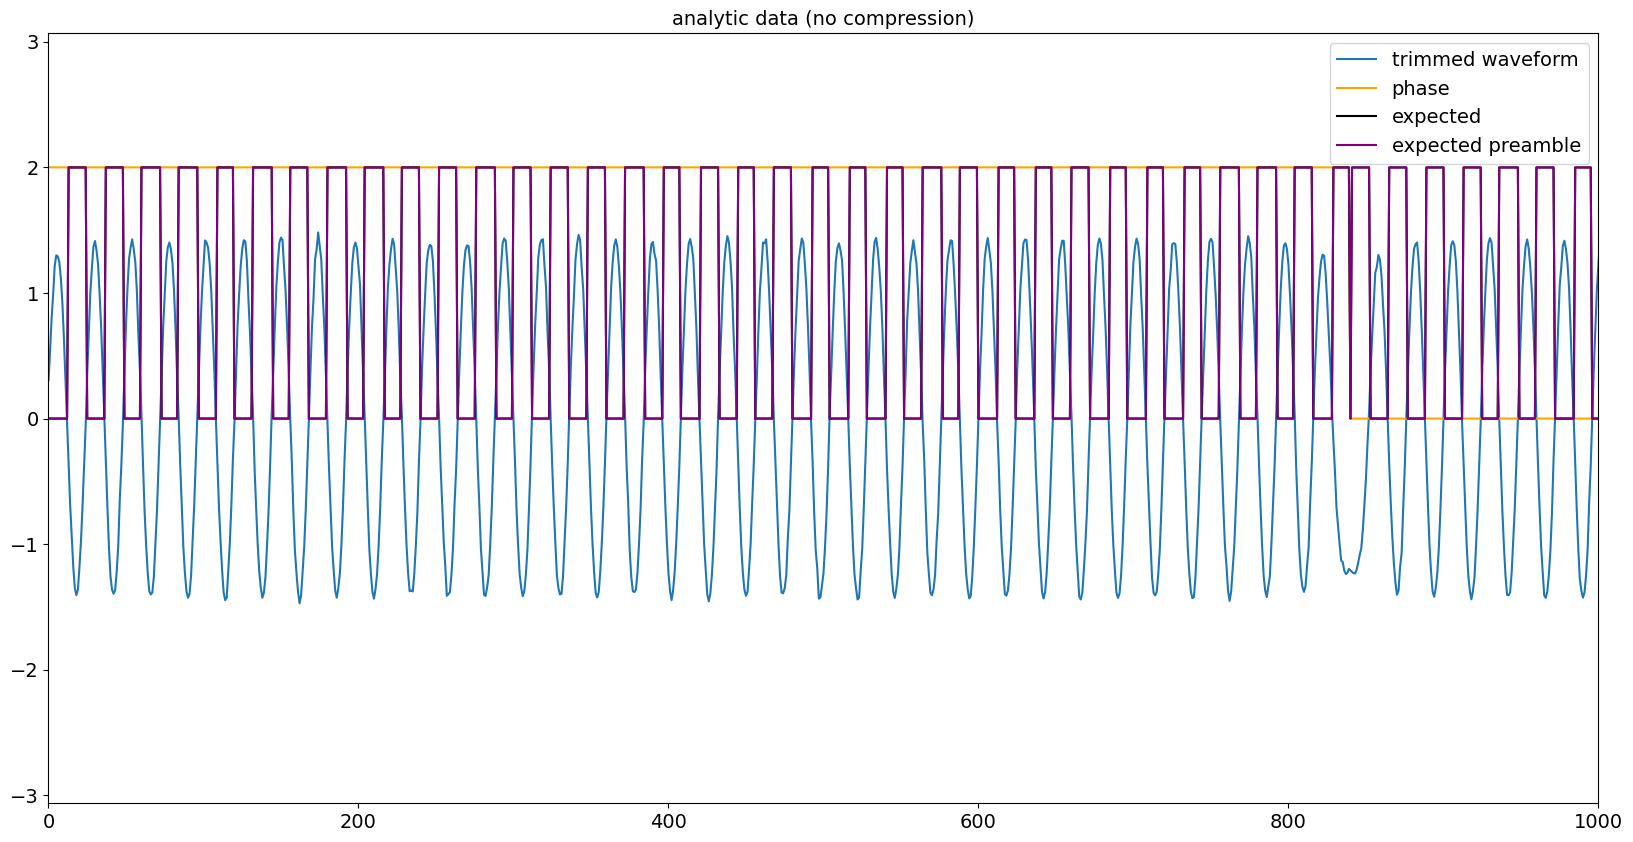

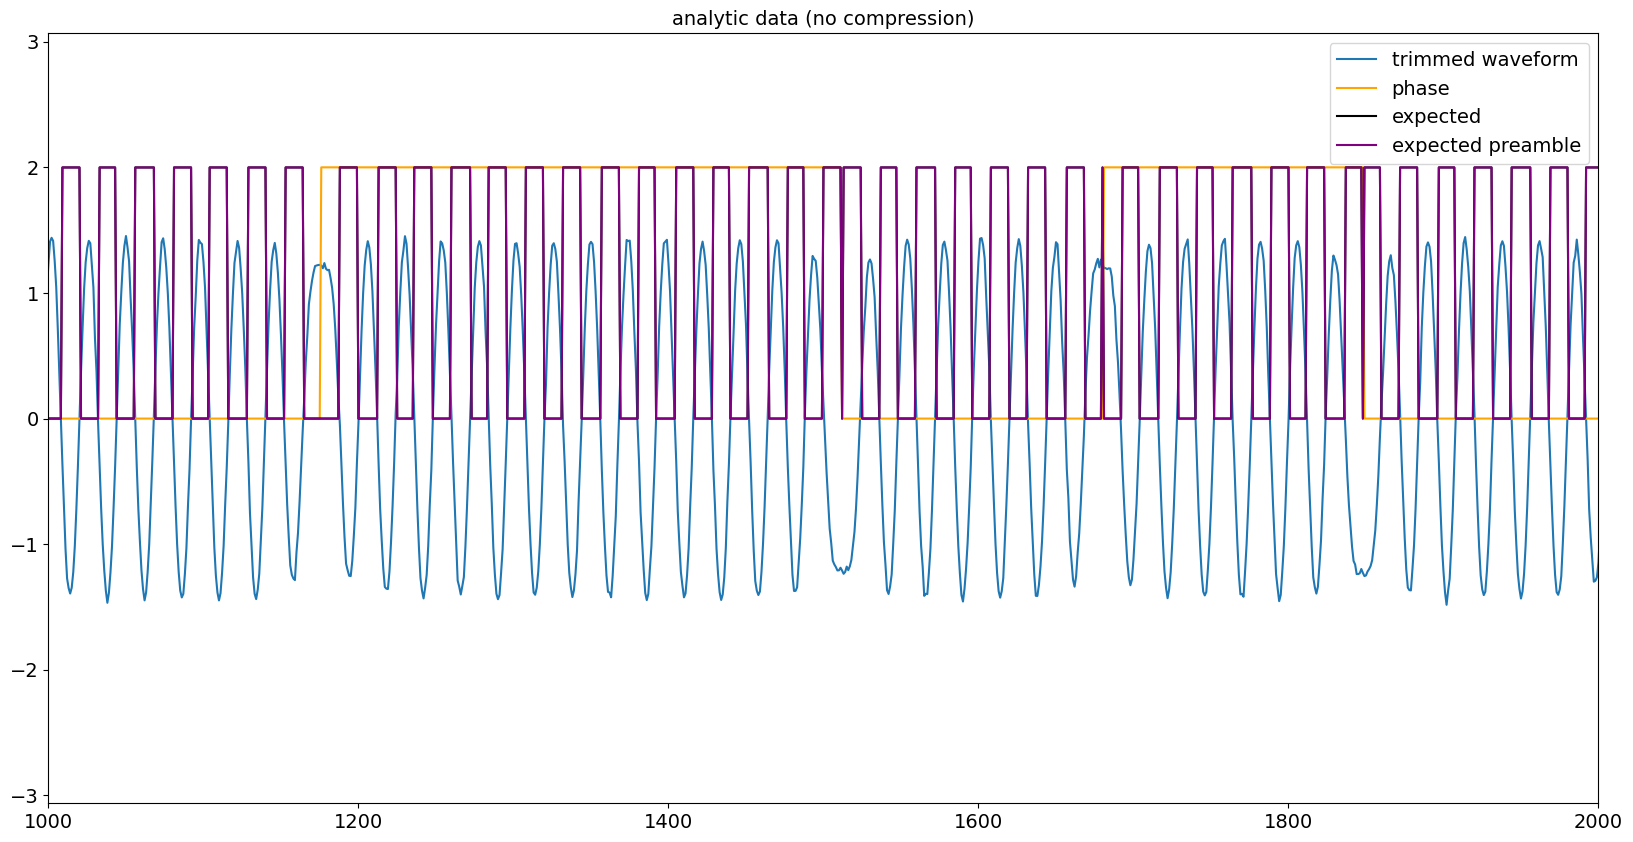

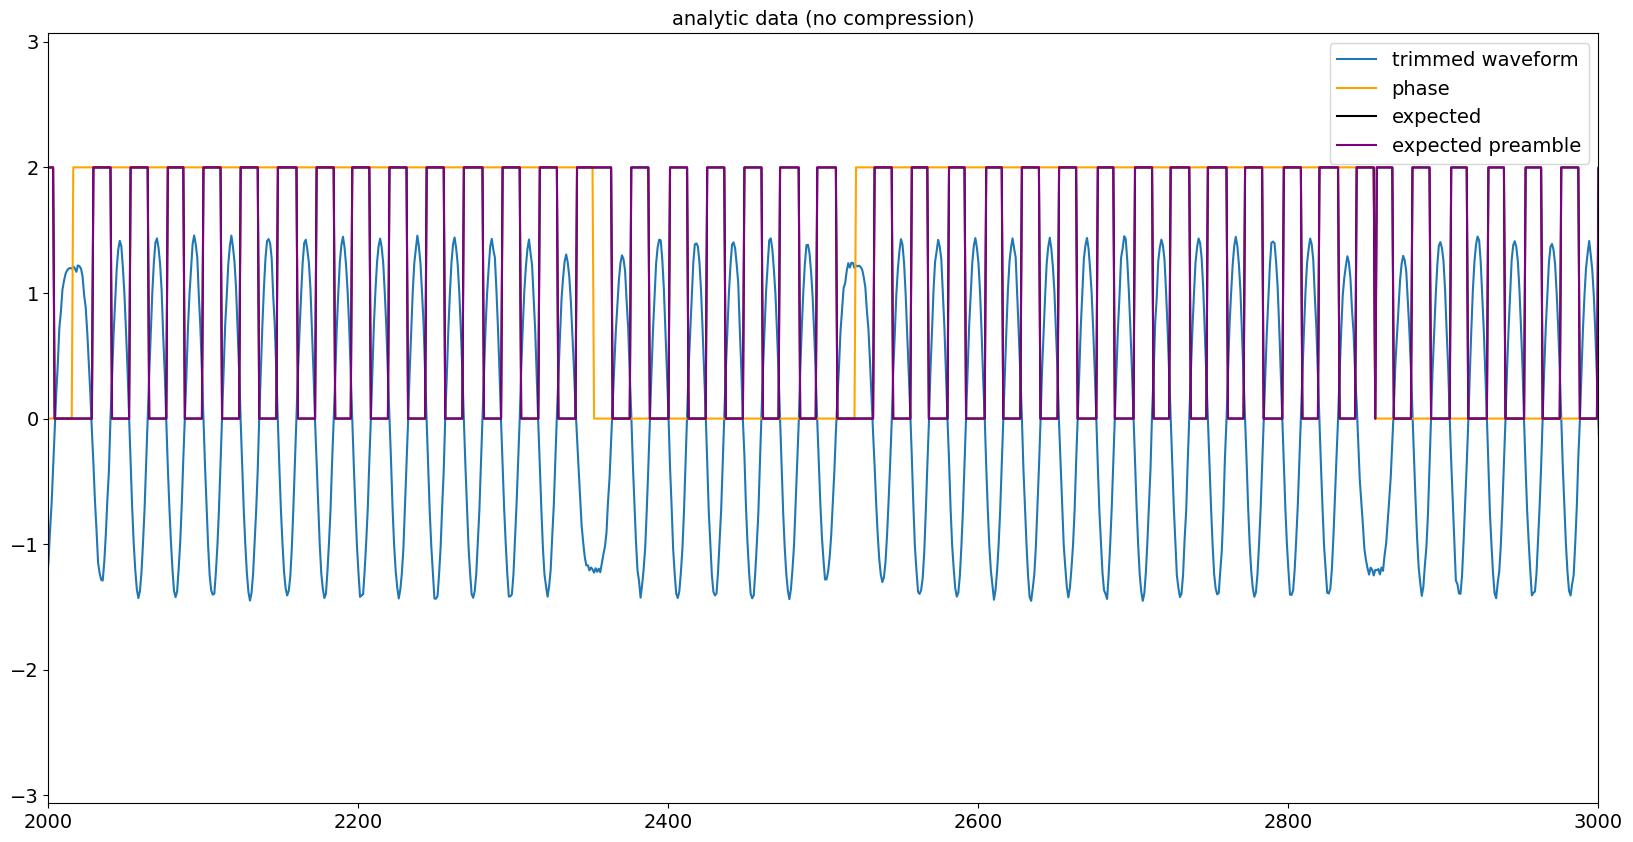

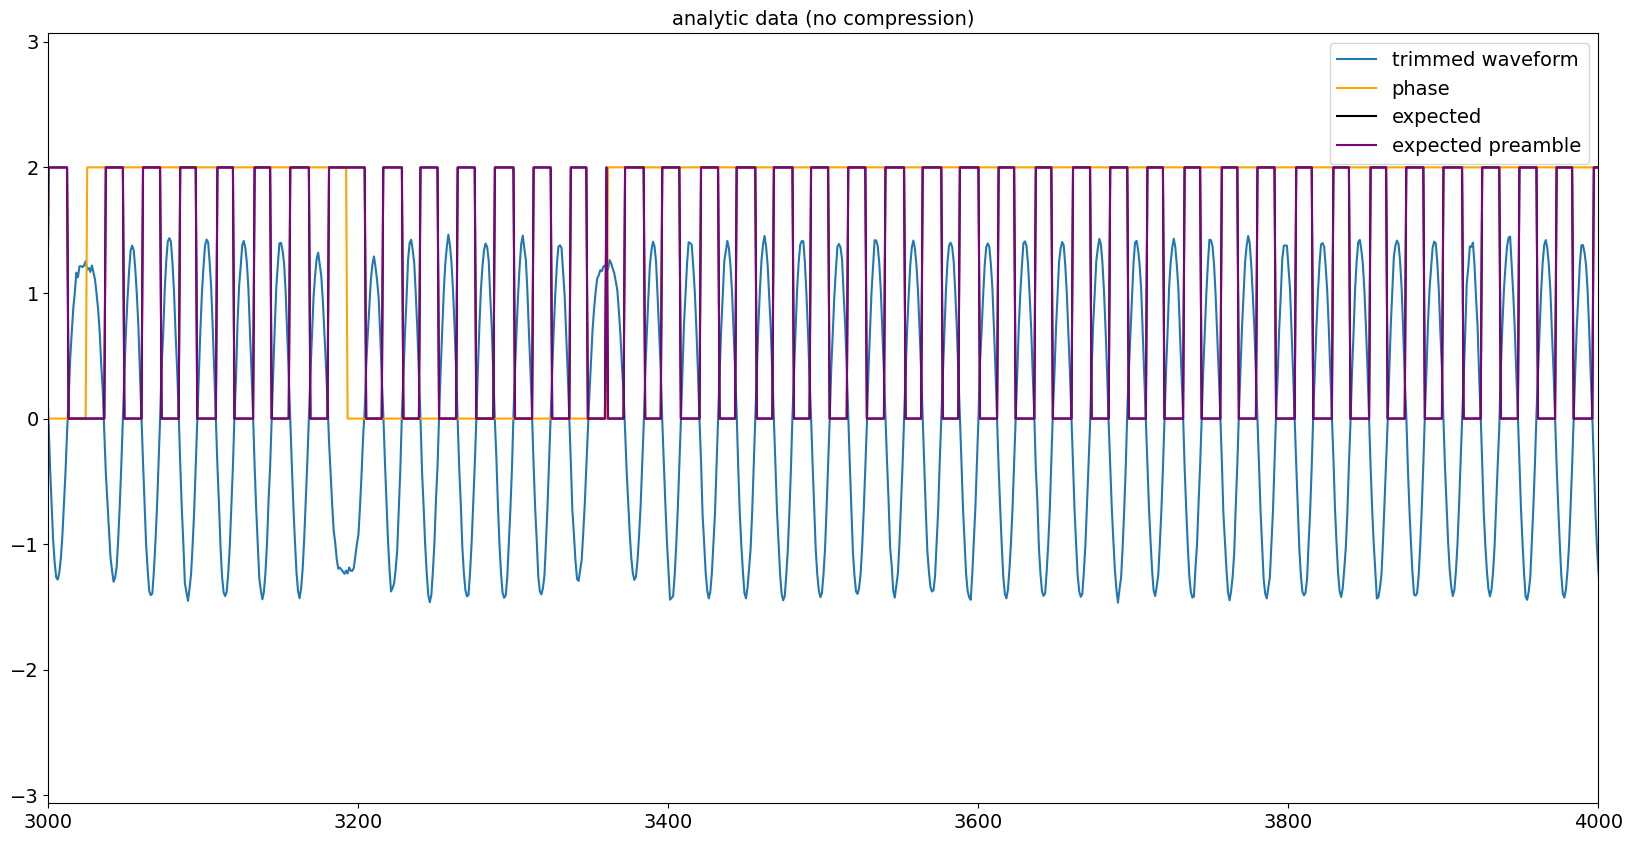

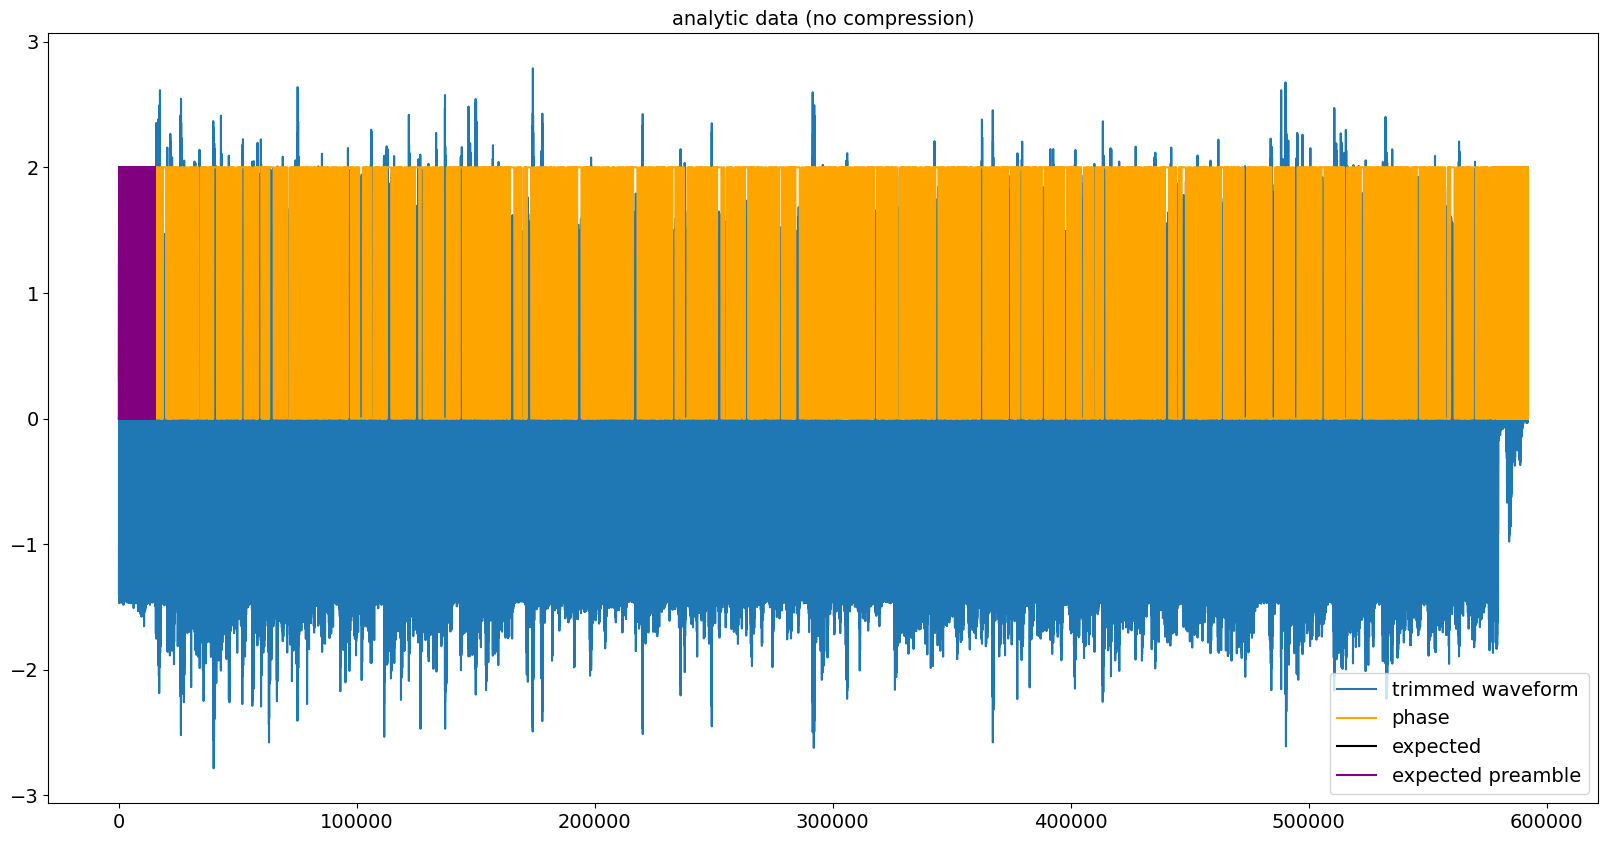

In [3]:
print_everything(analytic_data, "analytic data (no compression)")